# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank.ai_internship/blob/main/work/notebooks/w05_model.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method: Gradient Boosted Trees (LightGBM)**

LightGBM is chosen for the following reasons:

1. **Handles mixed feature types natively:** The feature vector contains both numeric and encoded categorical columns with varying scales. LightGBM handles these without normalization or one-hot explosion.
2. **Robust to missing values:** LightGBM can route missing values to the optimal branch during training — important since keyword columns are missing systematically for feedly articles.
3. **Produces calibrated probabilities:** With `objective='binary'`, LightGBM outputs P(declining) which directly ranks pages — ideal for Precision@50.
4. **Provides feature importance:** Enables explainability post-hoc: which signals drove each prediction.
5. **Fits on 30k rows fast:** LightGBM trains in seconds on this dataset size — no GPU needed.

**Alternatives considered:**
- **Logistic Regression:** Too linear; position × CTR interactions matter.
- **Random Forest:** Similar accuracy but slower and less calibrated probabilities.
- **Neural network:** Overkill for 30k rows and 30 features; harder to explain to clients.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Split: GroupShuffleSplit on `client_id` — 80% train / 20% test clients**

All pages from ~6–7 clients are withheld entirely for testing. The model never sees any page from these clients during training. This is honest because:
- The business question is generalization to new clients, not interpolation within known clients.
- Pages from the same client share the same CMS, industry, editorial style, and keyword strategy — row-level random split would leak this structure into the test set.
- This is consistent with the reference pipeline (`03_train_model.py`).

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm'], check=True)
    import lightgbm as lgb

# Load data
if os.path.exists('data/raw/content_refresh_anonymized.csv'):
    df_raw = pd.read_csv('data/raw/content_refresh_anonymized.csv')
else:
    df_raw = pd.read_csv('../data/raw/content_refresh_anonymized.csv')

df = df_raw.copy()
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

# Feature engineering (same as w03_feature_leakage_check)
for col in ['impressions_90d', 'clicks_90d', 'sessions_90d', 'ai_sessions_90d']:
    df[f'log_{col}'] = np.log1p(df[col].fillna(0))

df['click_per_impression'] = df['clicks_90d'] / df['impressions_90d'].clip(lower=1)
df['sessions_per_click'] = df['sessions_90d'] / df['clicks_90d'].clip(lower=1)
df['ai_session_ratio'] = df['ai_sessions_90d'] / df['sessions_90d'].clip(lower=1)
df['content_freshness_score'] = 1.0 / (df['days_since_last_update'] + 1)
df['has_keyword_data'] = (~df['search_volume'].isnull()).astype(int)
df['has_word_count'] = (~df['word_count'].isnull()).astype(int)

for col in ['search_volume', 'competition', 'cpc']:
    medians = df.groupby('content_type')[col].transform('median')
    df[col] = df[col].fillna(medians).fillna(0)

for col in ['word_count', 'char_count']:
    medians = df.groupby('content_type')[col].transform('median')
    df[col] = df[col].fillna(medians).fillna(df[col].median())

CAT_COLS = ['competition_level', 'content_type', 'main_intent',
            'age_tier', 'freshness_tier', 'word_count_tier',
            'impression_tier', 'position_tier']
for col in CAT_COLS:
    df[col] = df[col].fillna('MISSING')
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[CAT_COLS] = oe.fit_transform(df[CAT_COLS])

NUMERIC_FEATURES = [
    'search_volume', 'competition', 'cpc', 'word_count', 'char_count',
    'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'log_ai_sessions_90d',
    'days_with_impressions', 'days_with_sessions',
    'content_age_days', 'days_since_last_update',
    'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
    'click_per_impression', 'sessions_per_click', 'ai_session_ratio', 'content_freshness_score',
    'has_keyword_data', 'has_word_count',
]
ALL_FEATURES = NUMERIC_FEATURES + CAT_COLS

X = df[ALL_FEATURES].values
y = df['is_declining_label'].values
groups = df['client_id'].values

# Client-grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f'Train: {len(X_train):,} rows, {len(np.unique(groups_train))} clients')
print(f'Test:  {len(X_test):,} rows, {len(np.unique(groups[test_idx]))} clients')
print(f'Train label rate: {y_train.mean():.1%}')
print(f'Test label rate:  {y_test.mean():.1%}')

Train: 23,837 rows, 25 clients
Test:  6,163 rows, 7 clients
Train label rate: 55.0%
Test label rate:  51.1%


## 3. Train and evaluate the model

*Fit the model, compute AUC + Precision@50, compare to baseline.*

In [2]:
# Train LightGBM
params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False)]
)

# Predictions
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

# Precision@50
test_df = df.iloc[test_idx].copy()
test_df['model_prob'] = y_prob
test_df_sorted = test_df.sort_values('model_prob', ascending=False)
p_at_50_model = test_df_sorted.head(50)['is_declining_label'].mean()

print(f'LightGBM ROC-AUC: {auc:.4f}')
print(f'LightGBM Precision@50: {p_at_50_model:.1%}')
print(f'Best iteration: {model.best_iteration_}')

LightGBM ROC-AUC: 0.6340
LightGBM Precision@50: 88.0%
Best iteration: 145


In [3]:
# Compare to hand-rule baseline on the same test set
test_df['baseline_score'] = (
    0.25 * ((test_df['avg_position'].fillna(test_df['avg_position'].median()) - 
             test_df['avg_position'].min()) / 
            (test_df['avg_position'].max() - test_df['avg_position'].min())) +
    0.25 * ((test_df['days_since_last_update'].fillna(test_df['days_since_last_update'].median()) -
             test_df['days_since_last_update'].min()) /
            (test_df['days_since_last_update'].max() - test_df['days_since_last_update'].min())) +
    0.20 * (1 - (test_df['ctr'].fillna(test_df['ctr'].median()) - test_df['ctr'].min()) /
            (test_df['ctr'].max() - test_df['ctr'].min())) +
    0.20 * (1 - (test_df['engagement_rate'].fillna(test_df['engagement_rate'].median()) -
                 test_df['engagement_rate'].min()) /
            (test_df['engagement_rate'].max() - test_df['engagement_rate'].min())) +
    0.10 * (1 - (test_df['impressions_last_30d'] / test_df['impressions_prev_30d'].clip(lower=1)).clip(upper=2.0).fillna(1.0) / 2.0)
)
p_at_50_baseline = test_df.sort_values('baseline_score', ascending=False).head(50)['is_declining_label'].mean()

print('=== Comparison: Model vs Baseline ===')
print(f'Baseline Precision@50: {p_at_50_baseline:.1%}')
print(f'LightGBM Precision@50: {p_at_50_model:.1%}')
print(f'Improvement: {p_at_50_model - p_at_50_baseline:+.1%} absolute')
print(f'\nLightGBM AUC: {auc:.4f}')

=== Comparison: Model vs Baseline ===
Baseline Precision@50: 54.0%
LightGBM Precision@50: 88.0%
Improvement: +34.0% absolute

LightGBM AUC: 0.6340


## 4. Feature importance

*Which features did the model rely on most?*

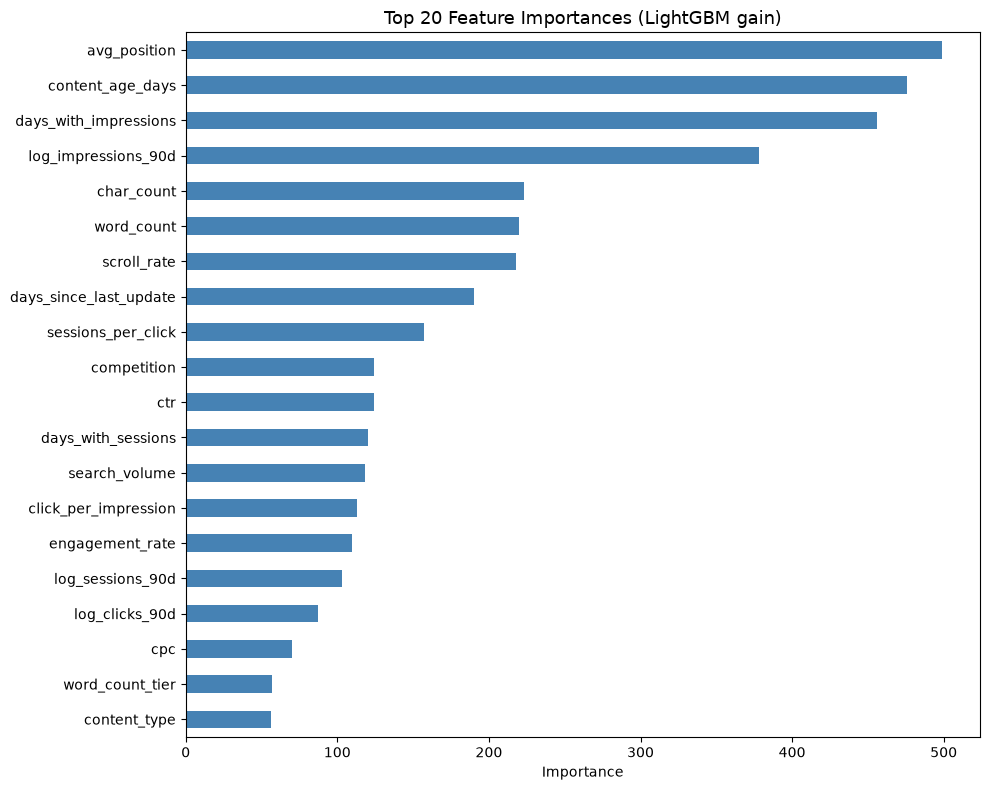

Top 10 features:
avg_position              499
content_age_days          476
days_with_impressions     456
log_impressions_90d       378
char_count                223
word_count                220
scroll_rate               218
days_since_last_update    190
sessions_per_click        157
competition               124
dtype: int32


In [4]:
import matplotlib.pyplot as plt

# Feature importance
fi = pd.Series(model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
fi.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (LightGBM gain)', fontsize=13)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
os.makedirs('work/outputs', exist_ok=True)
plt.savefig('work/outputs/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi.head(10).round(1))

In [5]:
# Save model predictions
test_df['model_prob'] = y_prob
output_cols = ['content_id', 'client_id', 'content_type', 'model_prob',
               'is_declining_label', 'avg_position', 'ctr', 'days_since_last_update']
test_df_sorted[output_cols].to_csv('work/outputs/model_predictions.csv', index=False)
print(f'Saved predictions to work/outputs/model_predictions.csv')

Saved predictions to work/outputs/model_predictions.csv
